This notebook extracts site‑specific daily climate time series from raw data sources.
Station data is processed first to establish the daily data contract before gridded extraction is added.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

# Ensure project root is on PYTHONPATH
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

In [2]:
import pandas as pd
from src.io import load_yaml, resolve_relative_path, resolve_output_path

# Load path configuration
paths = load_yaml("config/paths.yml")

### Load raw station CSV

In [3]:
df_station = pd.read_csv(
    resolve_relative_path(paths["raw_data"]["station_precip"]),
    comment="#",
)

df = df_station[
    [
        "LOCAL_DATE",
        "TOTAL_PRECIPITATION",
        "TOTAL_PRECIPITATION_FLAG",
        "MEAN_TEMPERATURE",
        "MIN_TEMPERATURE",
        "MAX_TEMPERATURE",
        "SNOW_ON_GROUND",
        "SNOW_ON_GROUND_FLAG",
    ]
].copy()

df["date"] = pd.to_datetime(df["LOCAL_DATE"]).dt.normalize()
df = df.drop(columns=["LOCAL_DATE"])

### Apply documented QC rules established in 00_data_inventory.ipynb
blank / NaN flag → keep value\
T (trace) → 0.0 mm\
E (estimated) → keep value\
M (missing) → missing

In [4]:
df.loc[df["TOTAL_PRECIPITATION_FLAG"] == "T", "TOTAL_PRECIPITATION"] = 0.0
df.loc[df["TOTAL_PRECIPITATION_FLAG"] == "M", "TOTAL_PRECIPITATION"] = pd.NA

df = df.rename(columns={
    "TOTAL_PRECIPITATION": "precip_mm",
    "MEAN_TEMPERATURE": "temp_mean_C",
    "MIN_TEMPERATURE": "temp_min_C",
    "MAX_TEMPERATURE": "temp_max_C",
    "SNOW_ON_GROUND": "snow_on_ground_cm",
})

df["temp_mean_C"] = pd.to_numeric(df["temp_mean_C"], errors="coerce")
df["snow_on_ground_cm"] = pd.to_numeric(df["snow_on_ground_cm"], errors="coerce")

In [5]:
daily_station_climate = (
    df[
        [
            "date",
            "precip_mm",
            "temp_mean_C",
            "snow_on_ground_cm",
        ]
    ]
    .sort_values("date")
    .reset_index(drop=True)
)

In [7]:
daily_station_climate.head()
daily_station_climate.tail()
daily_station_climate.isna().sum()

date                    0
precip_mm              95
temp_mean_C            86
snow_on_ground_cm    8036
dtype: int64

### Save to file

In [8]:
output_path = resolve_output_path(
    "data/interim/site_daily_climate_station.csv"
)

daily_station_climate.to_csv(output_path, index=False)

In [10]:
daily_station_climate.head(10)

,date,precip_mm,temp_mean_C,snow_on_ground_cm
0,1942-07-01,0.0,18.1,NaN
1,1942-07-02,1.5,15.6,NaN
2,1942-07-03,0.5,14.8,NaN
3,1942-07-04,0.0,15.0,NaN
4,1942-07-05,0.0,15.0,NaN
5,1942-07-06,0.0,17.0,NaN
6,1942-07-07,0.0,17.8,NaN
7,1942-07-08,0.0,19.7,NaN
8,1942-07-09,0.0,17.2,NaN
9,1942-07-10,0.0,16.7,NaN


In [11]:
daily_station_climate["precip_mm"].describe()

count    30416.000000
mean         0.725901
std          2.326200
min          0.000000
25%          0.000000
50%          0.000000
75%          0.400000
max         82.800000
Name: precip_mm, dtype: float64

In [12]:
daily_station_climate["snow_on_ground_cm"].describe()

count    22475.000000
mean        16.491034
std         18.127470
min          0.000000
25%          0.000000
50%         10.000000
75%         30.000000
max         81.000000
Name: snow_on_ground_cm, dtype: float64

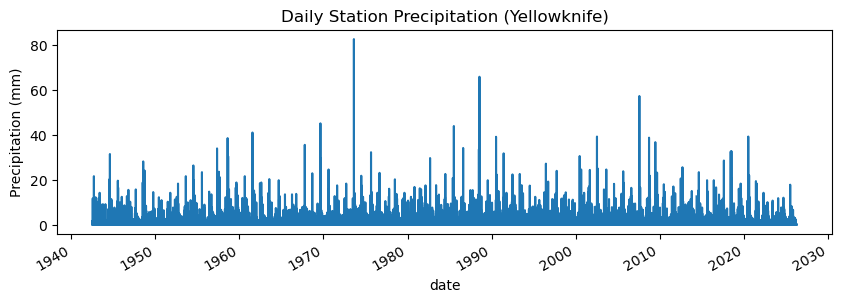

In [13]:
daily_station_climate.set_index("date")["precip_mm"].plot(
    figsize=(10, 3),
    title="Daily Station Precipitation (Yellowknife)"
)
plt.ylabel("Precipitation (mm)")
plt.show()

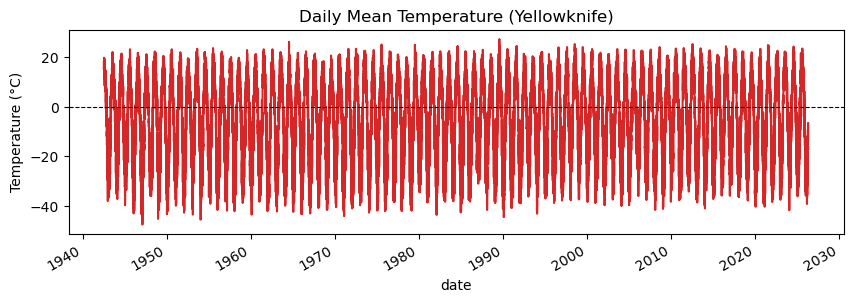

In [14]:
daily_station_climate.set_index("date")["temp_mean_C"].plot(
    figsize=(10, 3),
    title="Daily Mean Temperature (Yellowknife)",
    color="tab:red"
)
plt.ylabel("Temperature (°C)")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.show()

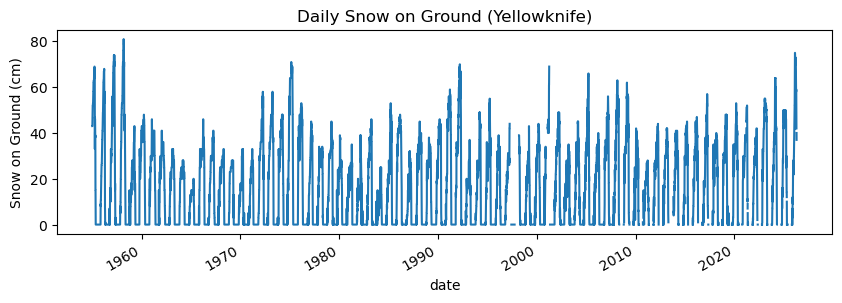

In [15]:
daily_station_climate.set_index("date")["snow_on_ground_cm"].plot(
    figsize=(10, 3),
    title="Daily Snow on Ground (Yellowknife)",
    color="tab:blue"
)
plt.ylabel("Snow on Ground (cm)")
plt.show()

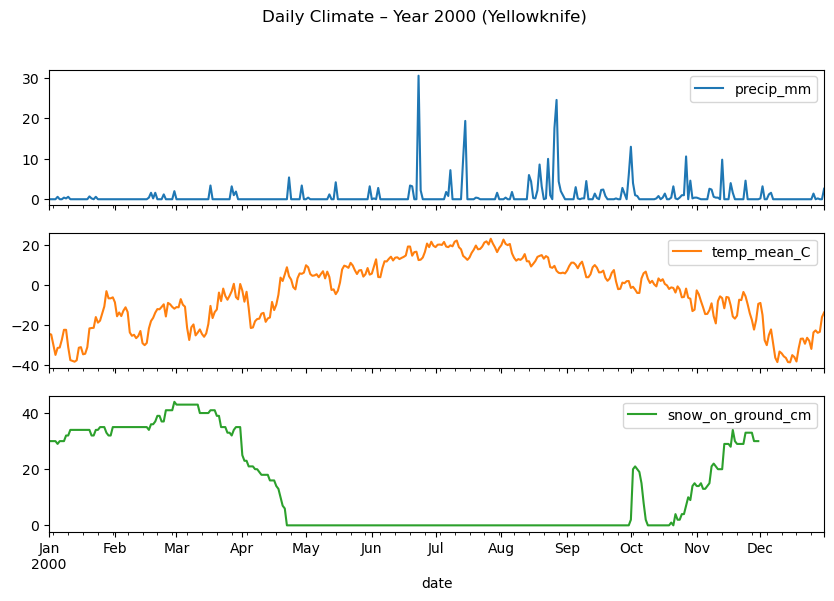

In [16]:
daily_station_climate[
    daily_station_climate["date"].dt.year == 2000
].set_index("date")[
    ["precip_mm", "temp_mean_C", "snow_on_ground_cm"]
].plot(
    subplots=True,
    figsize=(10, 6),
    title="Daily Climate – Year 2000 (Yellowknife)",
    layout=(3, 1),
    sharex=True
)
plt.show()